In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
dataset_path = r"C:\Users\aya\Desktop\QLF_code\dataset\UTKFace"

files = os.listdir(dataset_path)

print("Number of images:", len(files))
print(files[:5])

Number of images: 23708
['100_0_0_20170112213500903.jpg.chip.jpg', '100_0_0_20170112215240346.jpg.chip.jpg', '100_1_0_20170110183726390.jpg.chip.jpg', '100_1_0_20170112213001988.jpg.chip.jpg', '100_1_0_20170112213303693.jpg.chip.jpg']


In [3]:
ages = []

for file in files:
    try:
        age = int(file.split('_')[0])
        ages.append(age)
    except:
        continue

print("Number of extracted ages:", len(ages))
print("Example ages:", ages[:10])

Number of extracted ages: 23708
Example ages: [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]


In [4]:
labels = []

for age in ages:

    if age <= 17:
        labels.append("Child")

    elif age <= 59:
        labels.append("Adult")

    else:
        labels.append("Senior")

print(labels[:10])

['Senior', 'Senior', 'Senior', 'Senior', 'Senior', 'Senior', 'Senior', 'Senior', 'Senior', 'Senior']


In [5]:
import pandas as pd

df = pd.DataFrame({
    "age": ages,
    "label": labels
})

print(df["label"].value_counts())

label
Adult     16785
Child      4233
Senior     2690
Name: count, dtype: int64


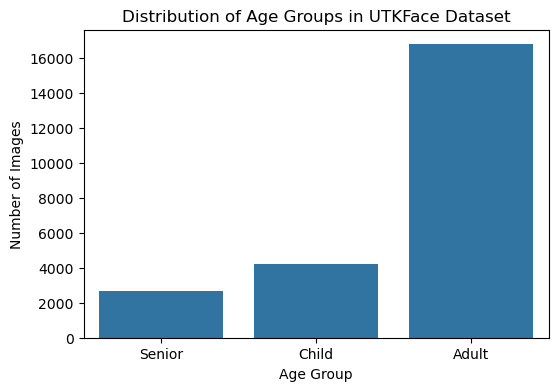

In [6]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x=labels)
plt.title("Distribution of Age Groups in UTKFace Dataset")
plt.xlabel("Age Group")
plt.ylabel("Number of Images")
plt.show()

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{'Adult': 0.47081719789494586, 'Child': 1.8669186550122057, 'Senior': 2.937794299876084}


In [8]:
label_map = {
    "Child": 0,
    "Adult": 1,
    "Senior": 2
}

numeric_labels = [label_map[label] for label in labels]

print(numeric_labels[:10])

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [9]:
image_paths = [os.path.join(dataset_path, file) for file in files]

print(image_paths[:3])

['C:\\Users\\aya\\Desktop\\QLF_code\\dataset\\UTKFace\\100_0_0_20170112213500903.jpg.chip.jpg', 'C:\\Users\\aya\\Desktop\\QLF_code\\dataset\\UTKFace\\100_0_0_20170112215240346.jpg.chip.jpg', 'C:\\Users\\aya\\Desktop\\QLF_code\\dataset\\UTKFace\\100_1_0_20170110183726390.jpg.chip.jpg']


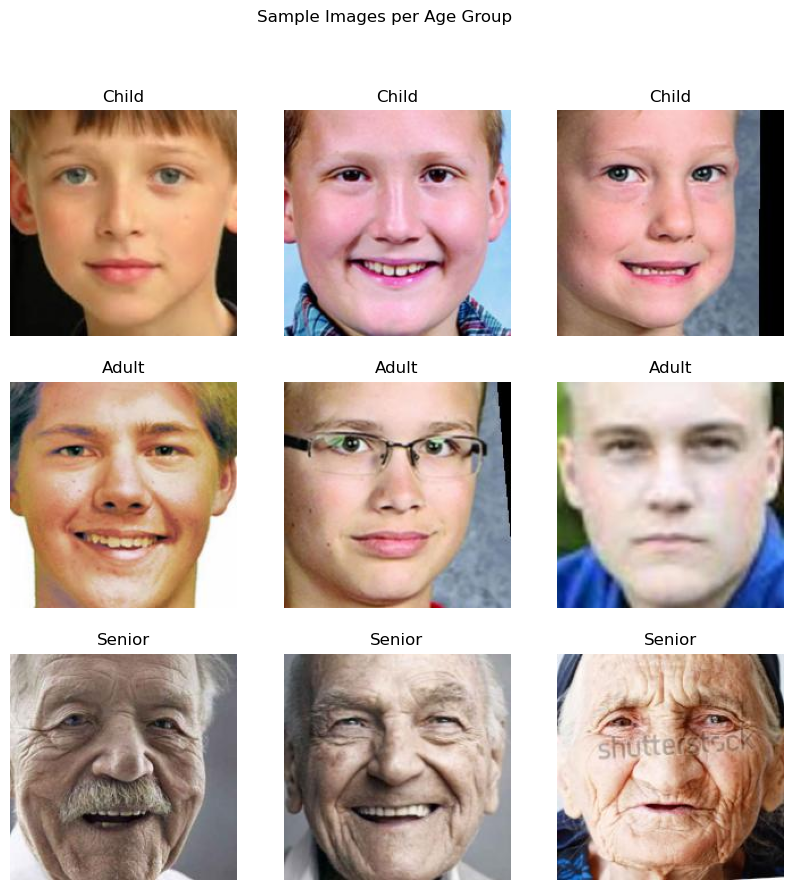

In [10]:
import cv2
import matplotlib.pyplot as plt

classes = ["Child", "Adult", "Senior"]

plt.figure(figsize=(10,10))

plot_index = 1

for c in classes:
    
    count = 0
    
    for i in range(len(labels)):
        
        if labels[i] == c:
            
            img = cv2.imread(image_paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(3,3,plot_index)
            plt.imshow(img)
            plt.title(c)
            plt.axis("off")
            
            plot_index += 1
            count += 1
            
        if count == 3:
            break

plt.suptitle("Sample Images per Age Group")
plt.show()

### Raw Image → MTCNN → Crop Face → Resize 224×224 → Normalize → X,y arrays 

In [12]:
pip install tensorflow

In [13]:
!pip install mtcnn

In [14]:
from mtcnn import MTCNN
import cv2
import numpy as np

detector = MTCNN()

In [15]:
from mtcnn import MTCNN
import cv2
import numpy as np

detector = MTCNN()

# test MTCNN
img_path = r"C:\Users\aya\Desktop\QLF_code\dataset\UTKFace\100_0_0_20170112213500903.jpg.chip.jpg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = detector.detect_faces(img_rgb)
print("Faces detected:", len(results))

Faces detected: 1


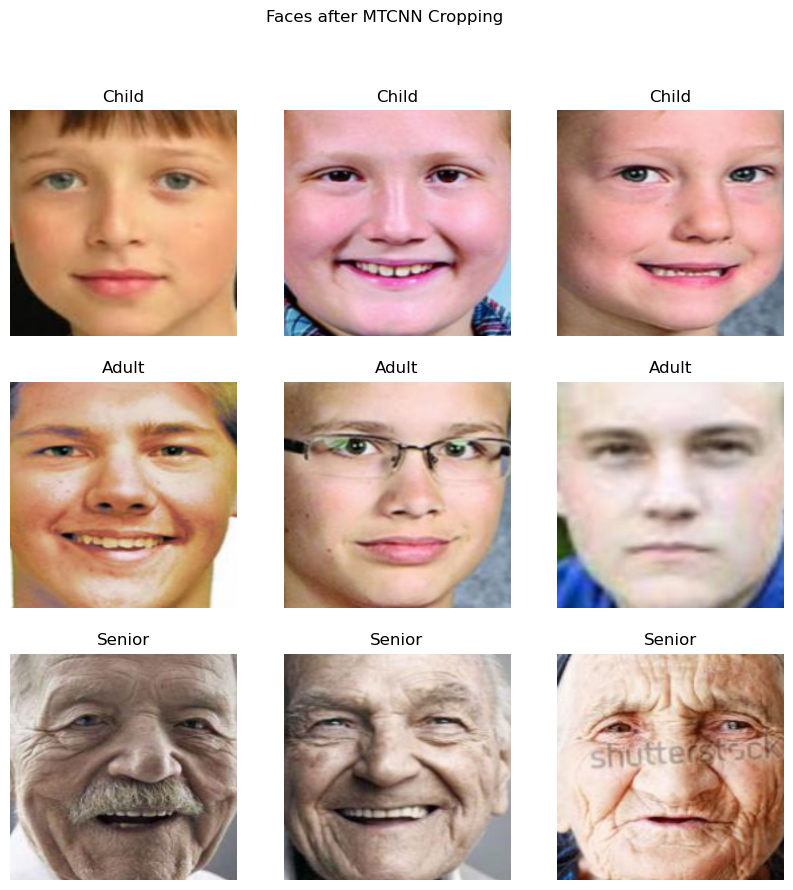

In [16]:
from mtcnn import MTCNN
import cv2
import numpy as np
import matplotlib.pyplot as plt

detector = MTCNN()

IMG_SIZE = 224

def crop_face(img_path):
    
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if len(results) == 0:
        return None

    x, y, width, height = results[0]['box']

    x, y = max(0, x), max(0, y)

    face = img_rgb[y:y+height, x:x+width]

    face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))

    face = face / 255.0

    return face


classes = ["Child", "Adult", "Senior"]

plt.figure(figsize=(10,10))

plot_index = 1

for c in classes:

    count = 0

    for i in range(len(labels)):

        if labels[i] == c:

            face = crop_face(image_paths[i])

            if face is not None:

                plt.subplot(3,3,plot_index)
                plt.imshow(face)
                plt.title(c)
                plt.axis("off")

                plot_index += 1
                count += 1

        if count == 3:
            break

plt.suptitle("Faces after MTCNN Cropping")
plt.show()

In [17]:
from mtcnn import MTCNN
import cv2
import os
import csv

# --- Paramètres ---
IMG_SIZE = 224
save_dir = "faces_dataset"
os.makedirs(save_dir, exist_ok=True)

csv_file = open("labels_corrected.csv", "w", newline="")
writer = csv.writer(csv_file)
writer.writerow(["image_name", "label"])

detector = MTCNN()
failed_images = []
saved_faces = 0

# --- Boucle sur les images ---
for i, img_path in enumerate(image_paths):

    try:
        # Lire et convertir en RGB
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Détection du visage
        results = detector.detect_faces(img_rgb)

        if len(results) == 0:
            failed_images.append(img_path)
            continue

        # Prendre le premier visage détecté
        x, y, width, height = results[0]['box']
        x, y = max(0, x), max(0, y)
        face = img_rgb[y:y+height, x:x+width]

        # Resize
        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))

        # Convertir RGB → BGR pour sauvegarde avec couleurs correctes
        face_bgr = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)

        # Sauvegarder l’image
        filename = os.path.basename(img_path)
        filepath = os.path.join(save_dir, filename)
        cv2.imwrite(filepath, face_bgr)

        # Écrire le label
        writer.writerow([filename, numeric_labels[i]])
        saved_faces += 1

    except Exception as e:
        failed_images.append(img_path)
        print(f"Error processing {img_path}: {e}")
        continue

    # Affichage du progrès
    if (i+1) % 500 == 0:
        print(f"Processed {i+1} images, Faces saved: {saved_faces}")

csv_file.close()

print("=== Terminé ===")
print("Total faces saved:", saved_faces)
print("Failed images:", len(failed_images))

Error processing C:\Users\aya\Desktop\QLF_code\dataset\UTKFace\105_1_0_20170112213507183.jpg.chip.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 48, 48, 3). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)
Error processing C:\Users\aya\Desktop\QLF_code\dataset\UTKFace\12_0_0_20170110232735095.jpg.chip.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 48, 48, 3). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=floa

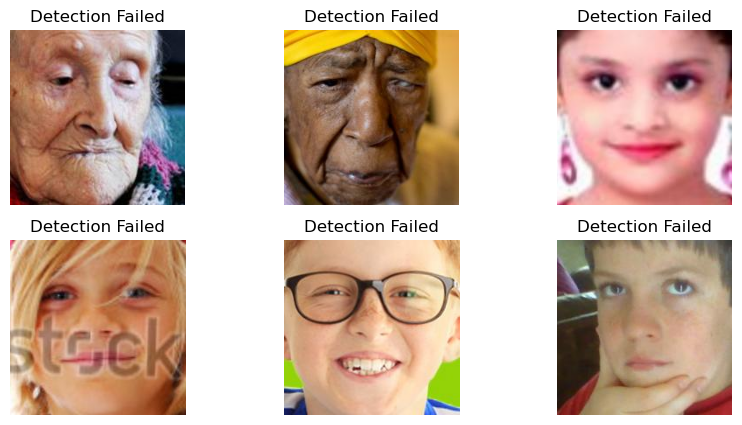

In [18]:
plt.figure(figsize=(10,5))

for i in range(min(6, len(failed_images))):

    img = cv2.imread(failed_images[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Detection Failed")
    plt.axis("off")

plt.show()

In [37]:
import pandas as pd

df = pd.read_csv("labels_corrected.csv")

print(df["label"].value_counts())

label
1    16691
0     4113
2     2652
Name: count, dtype: int64


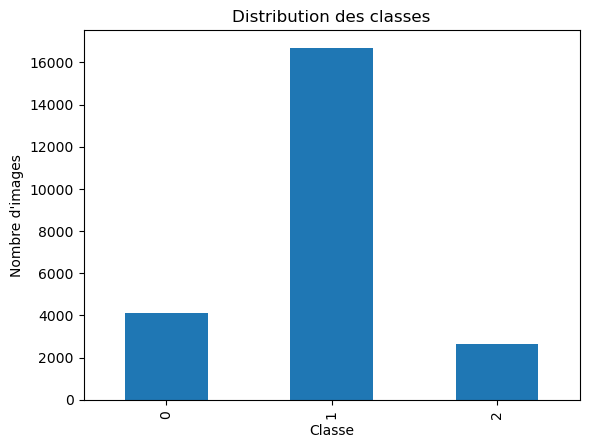

In [39]:
import matplotlib.pyplot as plt

df["label"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes")
plt.show()

In [41]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(df["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df["label"]
)

class_weights_dict = dict(zip(classes, class_weights))

print(class_weights_dict)

{0: 1.900964421752168, 1: 0.4684360833183552, 2: 2.9482151835093013}


In [45]:
import pandas as pd
import os

csv_path = "labels_corrected.csv"
faces_dir = "faces_dataset"

df = pd.read_csv(csv_path)

df["path"] = df["image_name"].apply(lambda x: os.path.join(faces_dir, x))

print(df.head())
print("Total images:", len(df))

                               image_name  label  \
0  100_0_0_20170112213500903.jpg.chip.jpg      2   
1  100_0_0_20170112215240346.jpg.chip.jpg      2   
2  100_1_0_20170110183726390.jpg.chip.jpg      2   
3  100_1_0_20170112213001988.jpg.chip.jpg      2   
4  100_1_0_20170112213303693.jpg.chip.jpg      2   

                                                path  
0  faces_dataset\100_0_0_20170112213500903.jpg.ch...  
1  faces_dataset\100_0_0_20170112215240346.jpg.ch...  
2  faces_dataset\100_1_0_20170110183726390.jpg.ch...  
3  faces_dataset\100_1_0_20170112213001988.jpg.ch...  
4  faces_dataset\100_1_0_20170112213303693.jpg.ch...  
Total images: 23456


In [47]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 16419
Validation: 3518
Test: 3519


### Calcul correct des class weights Avec train_df :

In [56]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Classes présentes dans le train set
classes = np.unique(train_df["label"])

# Calcul des class weights uniquement sur le train set
weights_train = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights_train = dict(zip(classes, weights_train))

print(class_weights_train)

{0: 1.9010072941993748, 1: 0.468418349880178, 2: 2.9488146551724137}


In [52]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

label
1    11684
0     2879
2     1856
Name: count, dtype: int64
label
1    2503
0     617
2     398
Name: count, dtype: int64
label
1    2504
0     617
2     398
Name: count, dtype: int64


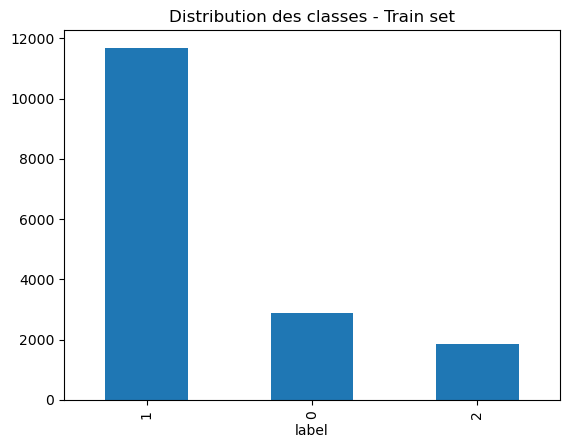

In [54]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot(kind="bar")
plt.title("Distribution des classes - Train set")
plt.show()

### mobilenetv2+softmax

Found 16419 validated image filenames belonging to 3 classes.
Found 3518 validated image filenames belonging to 3 classes.
Class weights: {0: 1.9010072941993748, 1: 0.468418349880178, 2: 2.9488146551724137}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 101s 11us/step
Epoch 1/50
514/514 ━━━━━━━━━━━━━━━━━━━━ 1805s 3s/step - accuracy: 0.7666 - loss: 0.4947 - val_accuracy: 0.3985 - val_loss: 4.4791 - learning_rate: 0.0010
Epoch 2/50
514/514 ━━━━━━━━━━━━━━━━━━━━ 1553s 3s/step - accuracy: 0.8295 - loss: 0.3378 - val_accuracy: 0.8110 - val_loss: 1.5099 - learning_rate: 0.0010
Epoch 3/50
514/514 ━━━━━━━━━━━━━━━━━━━━ 1627s 3s/step - accuracy: 0.8409 - loss: 0.3050 - val_accuracy: 0.3235 - val_loss: 3.3073 - learning_rate: 0.0010
Epoch 4/50
514/514 ━━━━━━━━━━━━━━━━━━━━ 1557s 3s/step - accuracy: 0.8568 - loss: 0.2740 - val_accuracy: 0.3712 - val_loss: 3.0311 - learning_rate: 0.0010
Epoch 5/50
514/514 ━━━━━━━━━━━━━━━━━━━━ 1594s 3s/step - accuracy: 0.8747 - loss: 0.2376 - val_accuracy: 0.6850 - val_loss: 1.

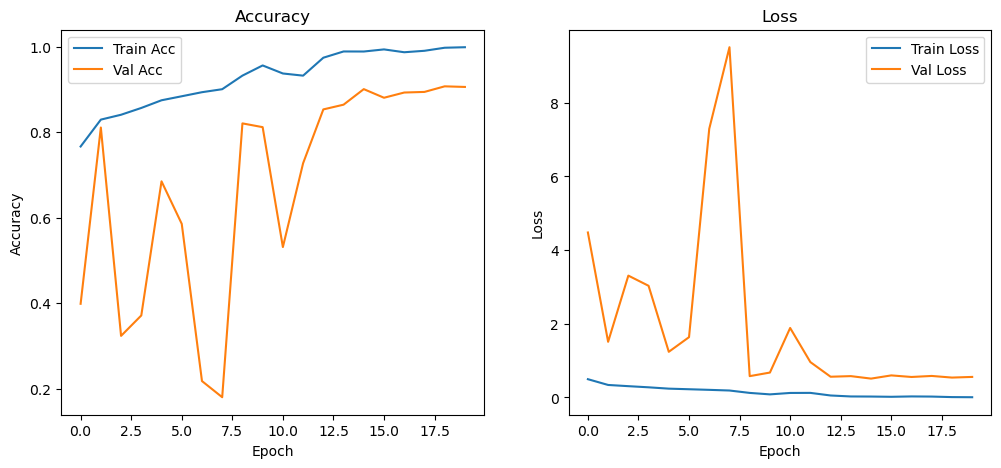

In [60]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# --- Paramètres ---
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
DATA_DIR = "faces_dataset"

# --- Conversion labels en string pour flow_from_dataframe ---
train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

# --- Générateurs ---
train_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATA_DIR,
    x_col="image_name",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=DATA_DIR,
    x_col="image_name",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# --- Class Weights sur train_df ---
classes = np.unique(train_df["label"])
weights_train = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label"])
class_weights_train = dict(zip(range(len(classes)), weights_train))
print("Class weights:", class_weights_train)

# --- MobileNetV2 + Softmax ---
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(classes), activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=outputs)

# --- Compiler ---
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

# --- Entraînement ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights_train,
    callbacks=[early_stop, reduce_lr]
)

# --- Courbes train/val ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### sauvegarde du model , epoch 15 

In [66]:
model.save("mobilenetv2_face_model.keras")

In [68]:
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=DATA_DIR,
    x_col="image_name",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 3519 validated image filenames belonging to 3 classes.


In [70]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

110/110 ━━━━━━━━━━━━━━━━━━━━ 81s 717ms/step


In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       617
           1       0.92      0.95      0.93      2504
           2       0.84      0.61      0.71       398

    accuracy                           0.90      3519
   macro avg       0.87      0.82      0.84      3519
weighted avg       0.90      0.90      0.90      3519



### matrix confusion 

[[ 559   58    0]
 [  79 2377   48]
 [   6  149  243]]


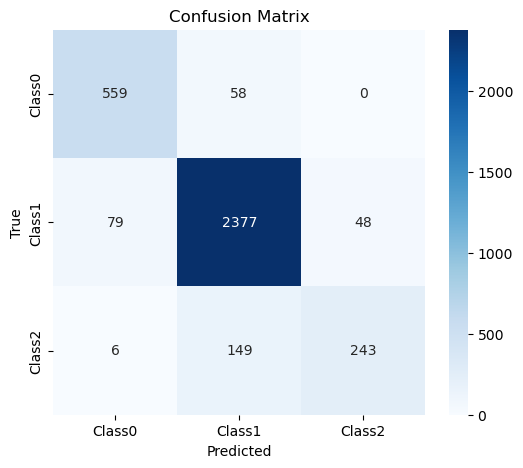

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Class0","Class1","Class2"],
            yticklabels=["Class0","Class1","Class2"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()